# Two-Seed Subject-Aware Item Autoencoder

## Data loading and setup

In [7]:
import ast
import copy
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from utils import load_public_test_csv, load_train_sparse, load_valid_csv

# train_np shape: [542, 1774]
train_np = load_train_sparse('./data').toarray().astype(np.float32)
responses = torch.tensor(np.nan_to_num(train_np, nan=0.0))
observed = torch.tensor(~np.isnan(train_np))
valid_data = load_valid_csv('./data')
test_data = load_public_test_csv('./data')

# Multi-hot subject vector for each question.
question_meta = pd.read_csv('./data/question_meta.csv')
subject_lists = question_meta['subject_id'].map(ast.literal_eval)
num_subjects = 1 + max(subject for subjects in subject_lists for subject in subjects)
subject_features = np.zeros((responses.shape[1], num_subjects), dtype=np.float32)
for question_id, subjects in zip(question_meta['question_id'], subject_lists):
    subject_features[int(question_id), subjects] = 1.0
subject_features = torch.tensor(subject_features)

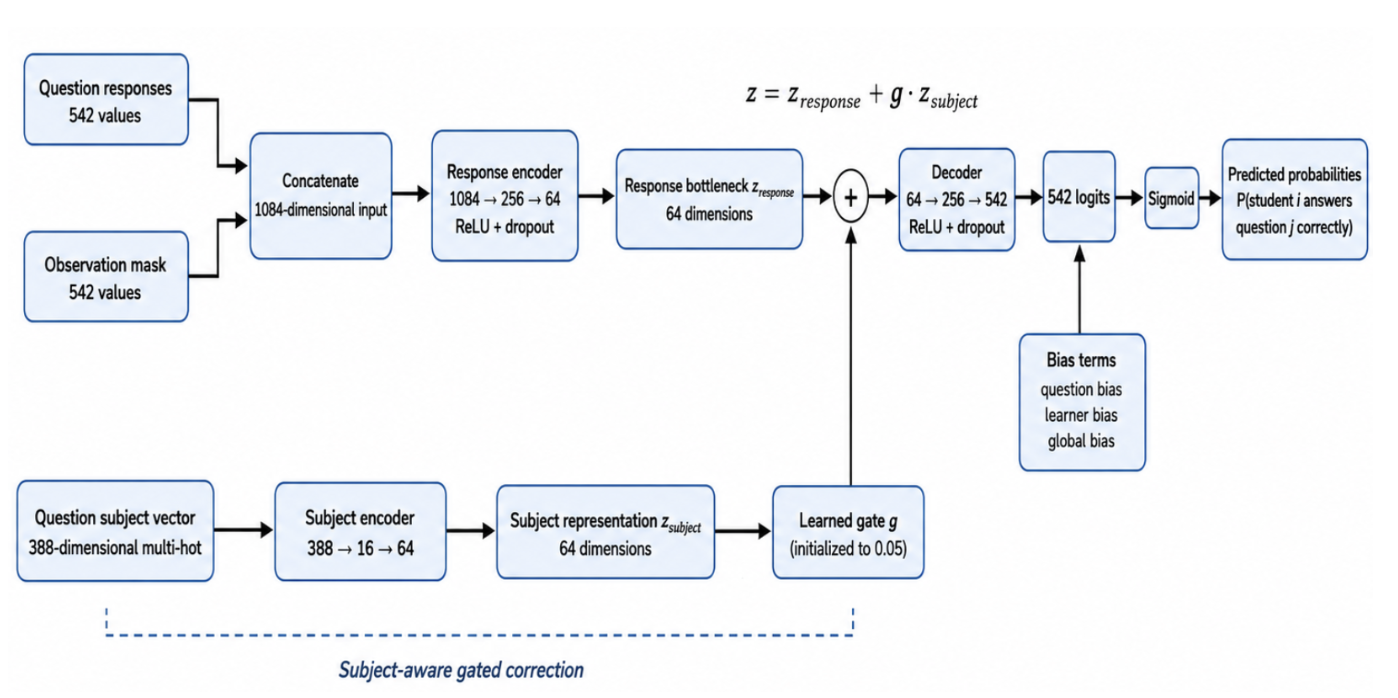

## Model Setup

In [8]:
class SubjectItemAutoEncoder(nn.Module):
    def __init__(self, num_learners, num_questions, num_subjects):
        super().__init__()

        # question/oberservation branch
        self.encoder_1 = nn.Linear(2 * num_learners, 256)
        self.encoder_2 = nn.Linear(256, 64)
        self.decoder_1 = nn.Linear(64, 256)
        self.decoder_2 = nn.Linear(256, num_learners)
        self.question_bias = nn.Embedding(num_questions, 1)
        self.learner_bias = nn.Parameter(torch.zeros(num_learners))
        self.global_bias = nn.Parameter(torch.zeros(()))
        nn.init.zeros_(self.question_bias.weight)

        # Small subject branch: 388 subject indicators -> 16 -> 64
        self.subject_encoder = nn.Sequential(nn.Linear(num_subjects, 16), nn.ReLU())
        self.subject_to_bottleneck = nn.Linear(16, 64)
        self.subject_gate = nn.Parameter(torch.tensor(0.05))

    def forward(self, answer_values, answer_mask, question_ids, question_subjects):
        x = torch.cat([answer_values, answer_mask.float()], dim=1)
        x = F.dropout(F.relu(self.encoder_1(x)), p=0.25, training=self.training)
        x = F.dropout(F.relu(self.encoder_2(x)), p=0.25, training=self.training)
        subject_z = self.subject_to_bottleneck(self.subject_encoder(question_subjects))
        x = x + self.subject_gate * subject_z
        x = F.dropout(F.relu(self.decoder_1(x)), p=0.25, training=self.training)
        logits = self.decoder_2(x)
        return logits + self.question_bias(question_ids) + self.learner_bias + self.global_bias

# Evaluation

In [9]:
@torch.no_grad()
def predict_probabilities(model, data):
    """Return probabilities and labels for a validation or test split."""
    model.eval()
    question_ids = torch.arange(responses.shape[1])
    logits = model(responses.T, observed.T, question_ids, subject_features)
    users = torch.as_tensor(data['user_id'], dtype=torch.long)
    questions = torch.as_tensor(data['question_id'], dtype=torch.long)
    labels = torch.as_tensor(data['is_correct'], dtype=torch.float32)
    return torch.sigmoid(logits[questions, users]), labels

## Training loop

In [10]:

def train_item_autoencoder(seed, max_epochs=140, batch_size=32):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    num_learners, num_questions = responses.shape
    model = SubjectItemAutoEncoder(num_learners, num_questions, subject_features.shape[1])
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    targets, masks = responses.T, observed.T
    best_accuracy, best_epoch, best_state = -1.0, -1, None

    for epoch in range(max_epochs):
        model.train()
        permutation = torch.randperm(num_questions)
        for start in range(0, num_questions, batch_size):
            question_ids = permutation[start:start + batch_size]
            logits = model(targets[question_ids], masks[question_ids], question_ids, subject_features[question_ids])
            loss = F.binary_cross_entropy_with_logits(
                logits[masks[question_ids]], targets[question_ids][masks[question_ids]]
            )
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        valid_probs, valid_labels = predict_probabilities(model, valid_data)
        valid_accuracy = ((valid_probs >= 0.5).float() == valid_labels).float().mean().item()
        if valid_accuracy > best_accuracy:
            best_accuracy = valid_accuracy
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    print(f'seed={seed}: best validation accuracy={best_accuracy:.4f} at epoch={best_epoch}')
    return model

## Train and evaluate the two-seed ensemble

In [11]:
# Train two independent models and average their probabilities
ensemble_seeds = (7, 31)
ensemble_members = [train_item_autoencoder(seed) for seed in ensemble_seeds]

valid_member_probs = [predict_probabilities(model, valid_data)[0] for model in ensemble_members]
ensemble_valid_probs = torch.stack(valid_member_probs).mean(dim=0)
valid_labels = predict_probabilities(ensemble_members[0], valid_data)[1]
ensemble_valid_accuracy = ((ensemble_valid_probs >= 0.5).float() == valid_labels).float().mean().item()
print(f'Ensemble validation accuracy (threshold=0.5): {ensemble_valid_accuracy:.4f}')

# Use the same fixed threshold for the final test evaluation
test_member_probs = [predict_probabilities(model, test_data)[0] for model in ensemble_members]
ensemble_test_probs = torch.stack(test_member_probs).mean(dim=0)
test_labels = predict_probabilities(ensemble_members[0], test_data)[1]
ensemble_test_accuracy = ((ensemble_test_probs >= 0.5).float() == test_labels).float().mean().item()
print(f'Ensemble test accuracy (threshold=0.5): {ensemble_test_accuracy:.4f}')

seed=7: best validation accuracy=0.7173 at epoch=4
seed=31: best validation accuracy=0.7135 at epoch=4
Ensemble validation accuracy (threshold=0.5): 0.7132
Ensemble test accuracy (threshold=0.5): 0.7104
